In [6]:
from pathlib import Path
import pickle
import pandas as pd


def load_logs_to_dataframe(
    base_path,
    algorithms,
    seeds,
    filename_prefix="fr3_pusht_",
):
    """
    Sweep over algorithms and seeds, load log pickles, and return a single
    pandas.DataFrame with extra columns 'algorithm' and 'seed'.

    Parameters
    ----------
    base_path : str or Path
        Directory in which the .pkl files are stored.
    algorithms : iterable
        Iterable of controller classes (or names). If controller classes
        are passed, their __name__ attribute is used.
    seeds : iterable
        Iterable of int seeds to sweep over.
    filename_prefix : str
        Prefix used when saving: f"{prefix}{ctrl.__class__.__name__}_seed{seed}.pkl"

    Returns
    -------
    df : pd.DataFrame
        Concatenated dataframe of all logs that were found.
    """
    base_path = Path(base_path)
    all_dfs = []

    for algo in algorithms:
        # Allow passing in classes or plain strings
        algo_name = algo.__name__ if hasattr(algo, "__name__") else str(algo)

        for seed in seeds:
            log_file = base_path / f"{filename_prefix}{algo_name}_seed{seed}.pkl"
            if not log_file.exists():
                # Skip silently or log a warning, depending on your preference
                continue

            with open(log_file, "rb") as f:
                log_list = pickle.load(f)

            # log_list is your self.log: a list of dicts
            df = pd.DataFrame(log_list)
            df["algorithm"] = algo_name
            df["seed"] = seed
            all_dfs.append(df)

    if not all_dfs:
        # Return empty dataframe with no rows if nothing found
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)


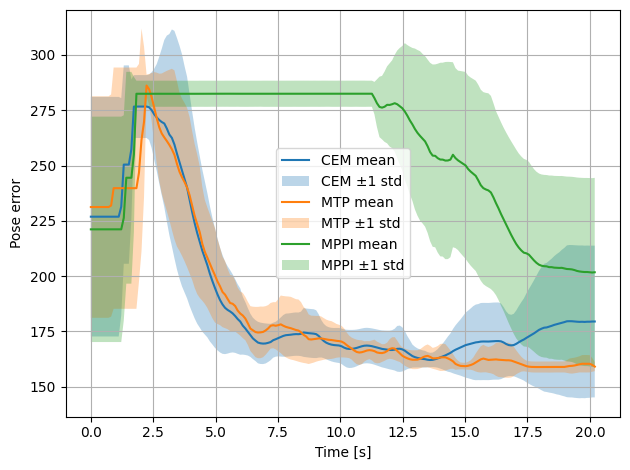

In [7]:
from hydrax.utils.files import get_data_path

import matplotlib.pyplot as plt
import numpy as np

algorithms = ["CEM", "MTP", "MPPI"]
seeds = [10, 11, 12, 13, 14]

path = get_data_path() / "sim-real"
df = load_logs_to_dataframe(str(path), algorithms, seeds)

plt.figure()

for algo in algorithms:
    algo_name = algo.__name__ if hasattr(algo, "__name__") else str(algo)
    df_algo = df[df["algorithm"] == algo_name]

    # Collect per-seed time and pose_error arrays
    time_arrays = []
    pose_arrays = []
    for seed in seeds:
        df_seed = df_algo[df_algo["seed"] == seed].sort_values("time")
        if df_seed.empty:
            continue
        time_arrays.append(df_seed["time"].to_numpy())
        pose_arrays.append(df_seed["pose_error"].to_numpy())

    if not time_arrays:
        continue

    # Build common time grid: union of all time stamps, or a regular grid if you prefer
    t_min = min(t[0] for t in time_arrays)
    t_max = max(t[-1] for t in time_arrays)
    # choose resolution; here: max number of samples across seeds
    max_len = max(len(t) for t in time_arrays)
    t_common = np.linspace(t_min, t_max, max_len)

    # Interpolate each seed onto common grid
    interp_pose = []
    for t, y in zip(time_arrays, pose_arrays):
        interp_y = np.interp(t_common, t, y)
        interp_pose.append(interp_y)

    interp_pose = np.stack(interp_pose, axis=0)  # shape: (n_seeds, T)

    mean = interp_pose.mean(axis=0)
    std = interp_pose.std(axis=0)

    plt.plot(t_common, mean, label=f"{algo_name} mean")
    plt.fill_between(
        t_common,
        mean - std,
        mean + std,
        alpha=0.3,
        label=f"{algo_name} ±1 std",
    )

plt.xlabel("Time [s]")
plt.ylabel("Pose error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

